In [12]:
import pandas as pd
import spacy
import re
nlp=spacy.load('en_core_web_sm')

In [13]:
sentences=pd.read_csv('childrens_books.csv')

In [14]:
sentences

,Ranking,Title,Author,Year,Rating,Description
0,1,Where the Wild Things Are,Maurice Sendak,1963,4.25,"Where the Wild Things Are follows Max, a young..."
1,2,The Very Hungry Caterpillar,Eric Carle,1969,4.34,The Very Hungry Caterpillar tells the story of...
2,3,The Giving Tree,Shel Silverstein,1964,4.38,The Giving Tree is a touching and bittersweet ...
3,4,Green Eggs and Ham,Dr. Seuss,1960,4.31,"In Green Eggs and Ham, Sam-I-Am tries to convi..."
4,5,Goodnight Moon,Margaret Wise Brown,1947,4.31,"Goodnight Moon is a gentle, rhythmic bedtime s..."
...,...,...,...,...,...,...
95,96,Stone Soup,Jon J. Muth,2003,4.18,Stone Soup is a classic folktale retold by Jon...
96,97,A Light in the Attic,Shel Silverstein,1981,4.36,A Light in the Attic is a collection of quirky...
97,98,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling,1999,4.58,Harry Potter and the Prisoner of Azkaban is th...
98,99,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,1998,4.43,Harry Potter and the Chamber of Secrets is the...


In [15]:
def remove_lower_pun(sentence):
    sentence=sentence.lower()
    sentence=re.sub(r'[^\w\s]', '', sentence)
    return sentence
sentences['Description']=sentences['Description'].apply(remove_lower_pun)



In [16]:
sentences

,Ranking,Title,Author,Year,Rating,Description
0,1,Where the Wild Things Are,Maurice Sendak,1963,4.25,where the wild things are follows max a young ...
1,2,The Very Hungry Caterpillar,Eric Carle,1969,4.34,the very hungry caterpillar tells the story of...
2,3,The Giving Tree,Shel Silverstein,1964,4.38,the giving tree is a touching and bittersweet ...
3,4,Green Eggs and Ham,Dr. Seuss,1960,4.31,in green eggs and ham samiam tries to convince...
4,5,Goodnight Moon,Margaret Wise Brown,1947,4.31,goodnight moon is a gentle rhythmic bedtime st...
...,...,...,...,...,...,...
95,96,Stone Soup,Jon J. Muth,2003,4.18,stone soup is a classic folktale retold by jon...
96,97,A Light in the Attic,Shel Silverstein,1981,4.36,a light in the attic is a collection of quirky...
97,98,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling,1999,4.58,harry potter and the prisoner of azkaban is th...
98,99,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,1998,4.43,harry potter and the chamber of secrets is the...


In [17]:
def token_lemma_stop(sentence):
    doc=nlp(sentence)
    output=[token.lemma_ for token in doc if not token.is_stop]
    return ' '.join(output)

sentences['Description']=sentences['Description'].apply(token_lemma_stop)

In [18]:
sentences

,Ranking,Title,Author,Year,Rating,Description
0,1,Where the Wild Things Are,Maurice Sendak,1963,4.25,wild thing follow max young boy send room mi...
1,2,The Very Hungry Caterpillar,Eric Carle,1969,4.34,hungry caterpillar tell story caterpillar ea...
2,3,The Giving Tree,Shel Silverstein,1964,4.38,give tree touching bittersweet story tree gi...
3,4,Green Eggs and Ham,Dr. Seuss,1960,4.31,green egg ham samiam try convince reluctant ...
4,5,Goodnight Moon,Margaret Wise Brown,1947,4.31,goodnight moon gentle rhythmic bedtime story...
...,...,...,...,...,...,...
95,96,Stone Soup,Jon J. Muth,2003,4.18,stone soup classic folktale retold jon j mut...
96,97,A Light in the Attic,Shel Silverstein,1981,4.36,light attic collection quirky poem illustrat...
97,98,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling,1999,4.58,harry potter prisoner azkaban book harry p...
98,99,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,1998,4.43,harry potter chamber secret second book ha...


In [24]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(stop_words='english',min_df=0.2)
processed_sentences=cv.fit_transform(sentences['Description'])


In [21]:
processed_sentences

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 3410 stored elements and shape (100, 1290)>

In [25]:
processed_sentences_df=pd.DataFrame(processed_sentences.toarray(),columns=cv.get_feature_names_out())

In [26]:
processed_sentences_df

,adventure,book,child,classic,explore,follow,friendship,illustration,make,read,reader,series,simple,story,tell,theme,young
0,1,1,0,0,1,1,0,1,0,0,0,0,0,1,0,1,1
1,0,1,1,1,0,0,0,1,0,0,1,0,1,2,1,0,1
2,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0
3,0,0,1,1,0,0,0,1,0,1,1,0,0,1,0,0,1
4,0,0,1,1,0,0,0,1,1,0,0,0,1,2,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0
96,0,1,1,0,1,0,0,2,0,0,0,0,0,0,0,0,0
97,0,1,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0
98,1,1,0,0,1,0,1,0,0,0,0,1,0,0,0,1,0


In [27]:
freq_text=processed_sentences_df.sum()

In [28]:
freq_text

adventure        39
book             75
child            66
classic          36
explore          30
follow           29
friendship       24
illustration     54
make             26
read             21
reader           54
series           28
simple           22
story           106
tell             29
theme            33
young            64
dtype: int64

<Axes: >

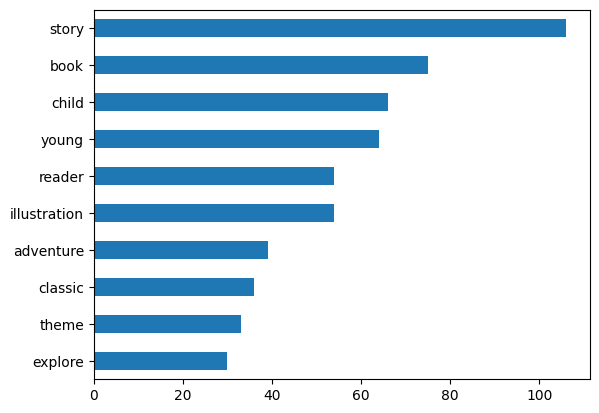

In [40]:
freq_text.sort_values().tail(10).plot(kind='barh')

In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf=TfidfVectorizer(stop_words='english',min_df=0.1,max_df=0.5)
tfidf_mat=tfidf.fit_transform(sentences['Description'])
tfidf_mat_df=pd.DataFrame(tfidf_mat.toarray(),columns=tfidf.get_feature_names_out())
tfidf_mat_df

,adventure,beloved,boy,character,charming,classic,courage,early,embark,engage,...,simple,tale,teach,tell,text,theme,timeless,way,whimsical,world
0,0.306065,0.000000,0.436081,0.00000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.310439,0.000000,0.000000,0.436081,0.000000
1,0.000000,0.357193,0.000000,0.00000,0.0,0.273303,0.000000,0.438717,0.0,0.0,...,0.344196,0.000000,0.000000,0.301902,0.415937,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.695432,0.00000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.356375,0.247534,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.37829,0.0,0.272536,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.418150,0.000000,0.00000,0.0,0.319944,0.000000,0.000000,0.0,0.0,...,0.402935,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.000000,0.000000,0.000000,0.00000,0.0,0.607668,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
96,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.463859,0.000000,0.474868,0.000000
97,0.000000,0.000000,0.000000,0.00000,0.0,0.000000,0.000000,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.336742,0.000000,0.000000,0.000000,0.462063
98,0.310365,0.000000,0.000000,0.00000,0.0,0.000000,0.465112,0.000000,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.314801,0.000000,0.000000,0.000000,0.000000


In [35]:
word_weight=tfidf_mat_df.sum()

In [36]:
word_weight

adventure       9.170431
beloved         5.736197
boy             5.522424
character       5.284426
charming        4.066705
classic         9.025850
courage         4.354438
early           3.515784
embark          3.678149
engage          5.490613
explore         7.930213
family          4.812912
favorite        3.648917
follow          7.539421
friendship      6.576614
fun             4.548425
gentle          3.641622
girl            3.970964
humor           5.984106
humorous        6.165330
imagination     4.255407
imaginative     3.781213
importance      3.663389
introduce       4.730778
joy             3.428162
learn           6.024657
lesson          6.497657
life            5.073379
little          5.550173
love            6.459629
magical         3.994955
make            6.980265
message         4.460692
narrative       4.375278
novel           4.386150
perfect         2.920536
playful         6.538079
read            5.878903
reader         11.410736
rhyme           4.685457


<Axes: >

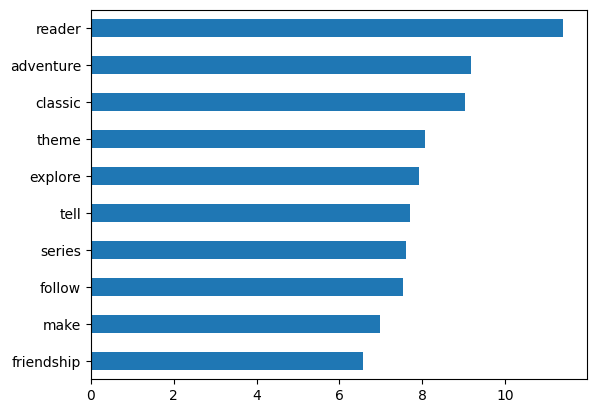

In [39]:
word_weight.sort_values().tail(10).plot(kind='barh')

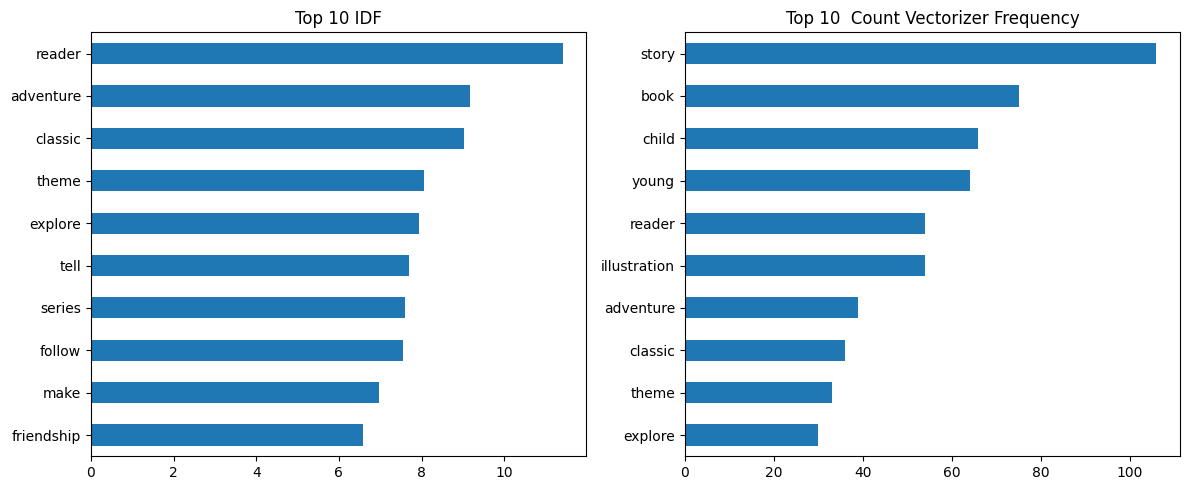

In [42]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# IDF plot
word_weight.sort_values().tail(10).plot(kind='barh', ax=axes[0], title='Top 10 IDF')

# Count Vectorizer plot
freq_text.sort_values().tail(10).plot(kind='barh', ax=axes[1], title='Top 10  Count Vectorizer Frequency')

plt.tight_layout()
plt.show()